<a href="https://colab.research.google.com/github/Divyansh-it19/24IT3019_DIVYANSH/blob/main/24IT3019_DIVYANSH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK-1 PROBLEM-1:

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import random
import os

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

print("Seeds set to 42")

print("\nPackage Versions:")
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)  # FIXED LINE

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU is available")
    print("Number of GPUs:", len(gpus))
else:
    print("\nNo GPU found")

    # CPU is slower because it has fewer cores and is not optimized for parallel operations.
    # GPU has many cores and can do matrix operations much faster.
    # On GPU machine, I would use GPU acceleration to train models faster.

Seeds set to 42

Package Versions:
TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0

GPU is available
Number of GPUs: 1


Why CPU training is slower and what to do on GPU:

CPU is slower because it has fewer cores and is not designed for parallel operations. Deep learning needs many matrix calculations which are faster on GPU. GPU has many cores and can do these calculations quickly. On a GPU machine, we use GPU acceleration to train models faster.

TASK-1 PROBLEM-2

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
MNIST train shape: (60000, 28, 28)
MNIST test shape: (10000, 28, 28)
CIFAR10 train shape: (50000, 32, 32, 3)
CIFAR10 test shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min: 0 max: 255

CIFAR10 dtype: uint8
CIFAR10 min: 0 max: 255

MNIST samples per class:
Class 0 : 5923
Class 1 : 6742
Class 2 : 5958
Class 3 : 6131
Class 4 : 5842
Class 5 : 5421
Class 6 : 5918
Class 7 : 6265
Class 8 : 5851
Class 9 : 5949


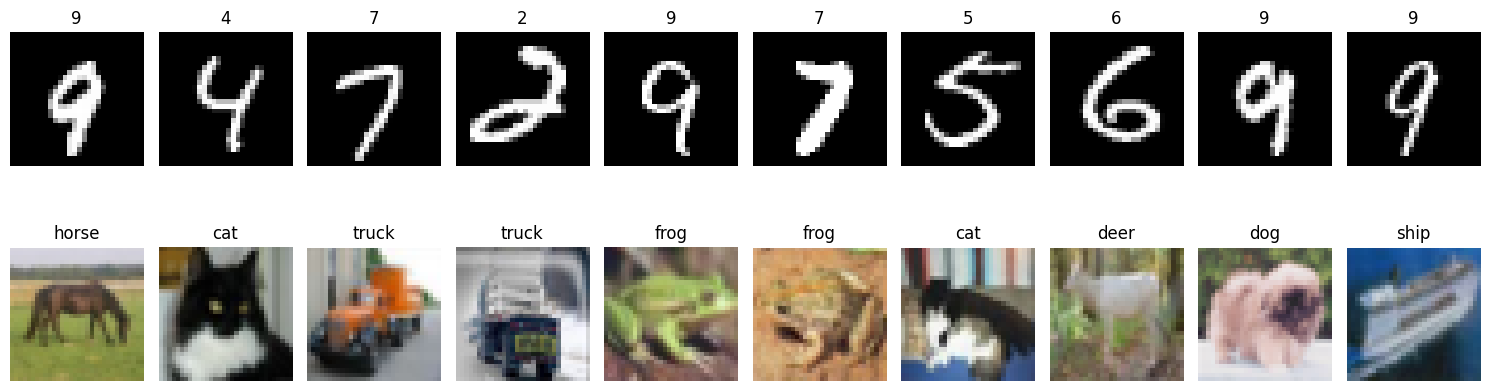

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Load datasets
(xm_train, ym_train), (xm_test, ym_test) = tf.keras.datasets.mnist.load_data()
(xc_train, yc_train), (xc_test, yc_test) = tf.keras.datasets.cifar10.load_data()

# (a) Shapes
print("MNIST train shape:", xm_train.shape)
print("MNIST test shape:", xm_test.shape)

print("CIFAR10 train shape:", xc_train.shape)
print("CIFAR10 test shape:", xc_test.shape)

# (b) Data type and range
print("\nMNIST dtype:", xm_train.dtype)
print("MNIST min:", xm_train.min(), "max:", xm_train.max())

print("\nCIFAR10 dtype:", xc_train.dtype)
print("CIFAR10 min:", xc_train.min(), "max:", xc_train.max())

# (c) Samples per class in MNIST
counts = np.bincount(ym_train)

print("\nMNIST samples per class:")
for i in range(len(counts)):
    print("Class", i, ":", counts[i])

# Plot images
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(15,5))

# MNIST row
for i in range(10):
    idx = random.randint(0, len(xm_train)-1)
    plt.subplot(2,10,i+1)
    plt.imshow(xm_train[idx], cmap='gray')
    plt.title(ym_train[idx])
    plt.axis('off')

# CIFAR row
for i in range(10):
    idx = random.randint(0, len(xc_train)-1)
    plt.subplot(2,10,i+11)
    plt.imshow(xc_train[idx])
    plt.title(class_names[yc_train[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

Text Answers (Markdown Cell)

(a) Shapes:
MNIST train: (60000, 28, 28), test: (10000, 28, 28)
CIFAR-10 train: (50000, 32, 32, 3), test: (10000, 32, 32, 3)

(b) Data type and range:
Both datasets use uint8. Values range from 0 to 255.

(c) Samples per class (MNIST):
Each class has around 6000 samples. Dataset is approximately balanced.

TASK-1 PROBLEM-3

In [3]:
import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Before processing:")
print("Shape:", x_train.shape)
print("Sample values:", x_train[0][0][:5])

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("\nAfter normalization:")
print("Min:", x_train.min(), "Max:", x_train.max())
print("Sample values:", x_train[0][0][:5])

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("\nAfter reshape:")
print("Shape:", x_train.shape)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("\nAfter one-hot encoding:")
print("Shape:", y_train.shape)
print("Sample label:", y_train[0])

Before processing:
Shape: (60000, 28, 28)
Sample values: [0 0 0 0 0]

After normalization:
Min: 0.0 Max: 1.0
Sample values: [0. 0. 0. 0. 0.]

After reshape:
Shape: (60000, 28, 28, 1)

After one-hot encoding:
Shape: (60000, 10)
Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Text Answer (Markdown Cell)

Pixel values are converted to range 0 to 1 by dividing by 255.
Images are reshaped to add channel dimension.
Labels are converted into one-hot vectors of length 10.

TASK-1 PROBLEM-4

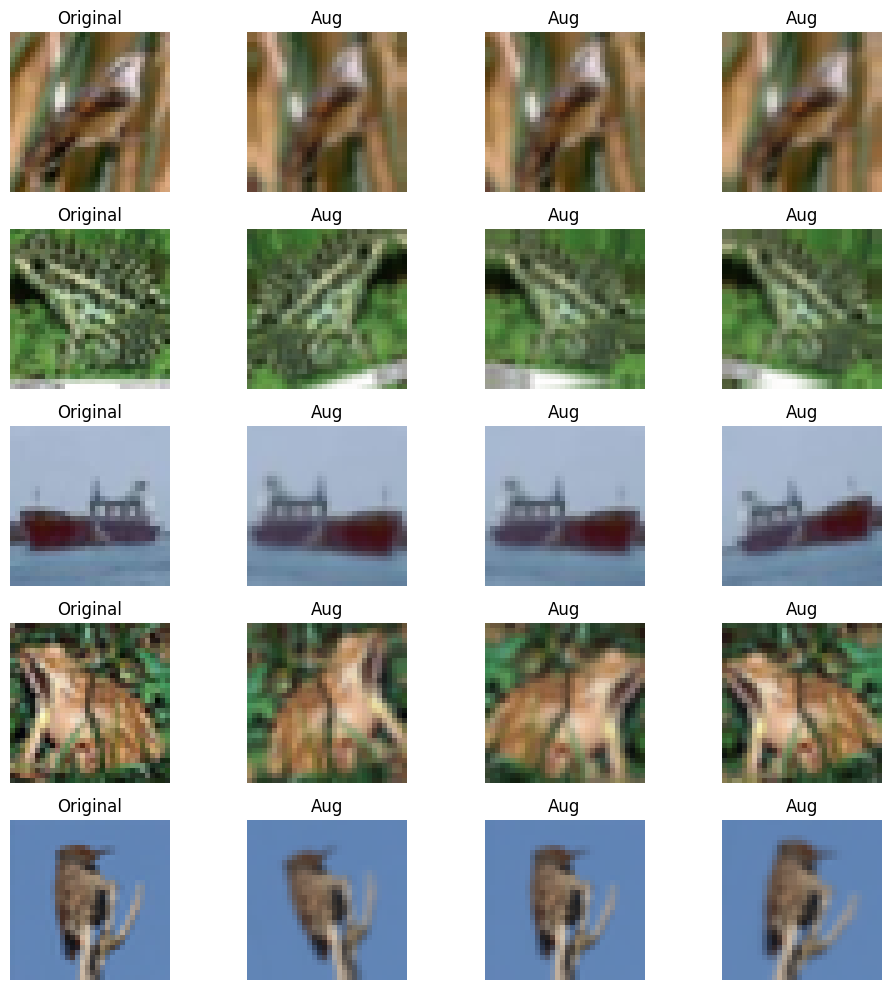

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

plt.figure(figsize=(10,10))

for i in range(5):
    idx = random.randint(0, len(x_train)-1)
    img = x_train[idx]

    plt.subplot(5,4,4*i+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    for j in range(3):
        aug_img = data_aug(tf.expand_dims(img, 0))
        aug_img = tf.squeeze(aug_img)

        plt.subplot(5,4,4*i+j+2)
        plt.imshow(aug_img)
        plt.title("Aug")
        plt.axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Text Answer (Markdown Cell)

Augmentation is applied only on training data to help the model learn better and generalize.
Validation and test data should remain unchanged to give a correct and fair evaluation of model performance.

Q1 Answer
Negative transfer means transfer learning makes performance worse instead of better.
This happens when the source data and target data are very different.
ImageNet has natural images like animals and objects. If the new task is very different, the learned features may not help.
Example: Medical images like X-rays or MRI scans. These are very different from normal images, so pre-trained weights may hurt performance.

Q2 Answer

Unfreezing all layers increases model complexity, so variance increases and overfitting happens.
Lower layers learn simple features like edges and shapes. These are general and useful for many tasks.
Upper layers learn specific features related to ImageNet classes, so they do not generalise well.
So freezing lower layers keeps general knowledge, while unfreezing too much causes overfitting.

Q3 Answer
Model size: Smaller models are better for mobile because of limited storage.
Inference speed: Fast models are needed for real-time use.
Power consumption: Efficient models save battery on mobile devices.
Memory usage: Less RAM usage is important for smooth performance.

These factors are important along with accuracy in real applications.